In [1]:
import pandas as pd
import utils as uti
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("../data/train_df.pkl")

In [3]:
import pickle
from pathlib import Path

file_path = Path("../data/models.pkl")

if file_path.exists():
    print('loading model file')
    with file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


In [4]:
models

{'logi': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x706811d61be0>}

# variable selection

In [5]:
walds = pd.read_pickle("../data/walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,V14,1951.546659,-0.099085,False
1,V4,1703.435651,-0.106422,False
2,V10,1617.13706,-0.102396,False
3,V3,1541.035483,-0.420856,True
4,V2,1478.19184,-0.530143,True


In [6]:
log_vars = walds[walds['corr ind'] == False]['var'].tolist()
# log_vars = walds['var'].tolist()
log_vars

['V14',
 'V4',
 'V10',
 'V11',
 'V12',
 'V16',
 'V18',
 'V9',
 'V17',
 'V1',
 'V6',
 'V19',
 'V21',
 'V8',
 'V27',
 'V28',
 'V24',
 'V13',
 'V15',
 'V23',
 'V26',
 'V22',
 'V25']

In [7]:
X = df[log_vars]
y = df.Class

In [8]:
selected_features, selection_history = uti.forward_select_auc(X, y)

print(f'Selected Features: {selected_features}')
print(selection_history)

Added V14                            CV AUC = 0.9479
Added V4                             CV AUC = 0.9725
Added V13                            CV AUC = 0.9757
Added V12                            CV AUC = 0.9776
Added V16                            CV AUC = 0.9791
Added V8                             CV AUC = 0.9802
Selected Features: ['V14', 'V4', 'V13', 'V12', 'V16', 'V8']
  added                      features    cv_auc
0   V14                         [V14]  0.947890
1    V4                     [V14, V4]  0.972541
2   V13                [V14, V4, V13]  0.975724
3   V12           [V14, V4, V13, V12]  0.977612
4   V16      [V14, V4, V13, V12, V16]  0.979090
5    V8  [V14, V4, V13, V12, V16, V8]  0.980207


In [9]:
selected_features

['V14', 'V4', 'V13', 'V12', 'V16', 'V8']

In [10]:
df.groupby('Class').size()

Class
0.0    227451
1.0       394
dtype: int64

# pair plot of selected

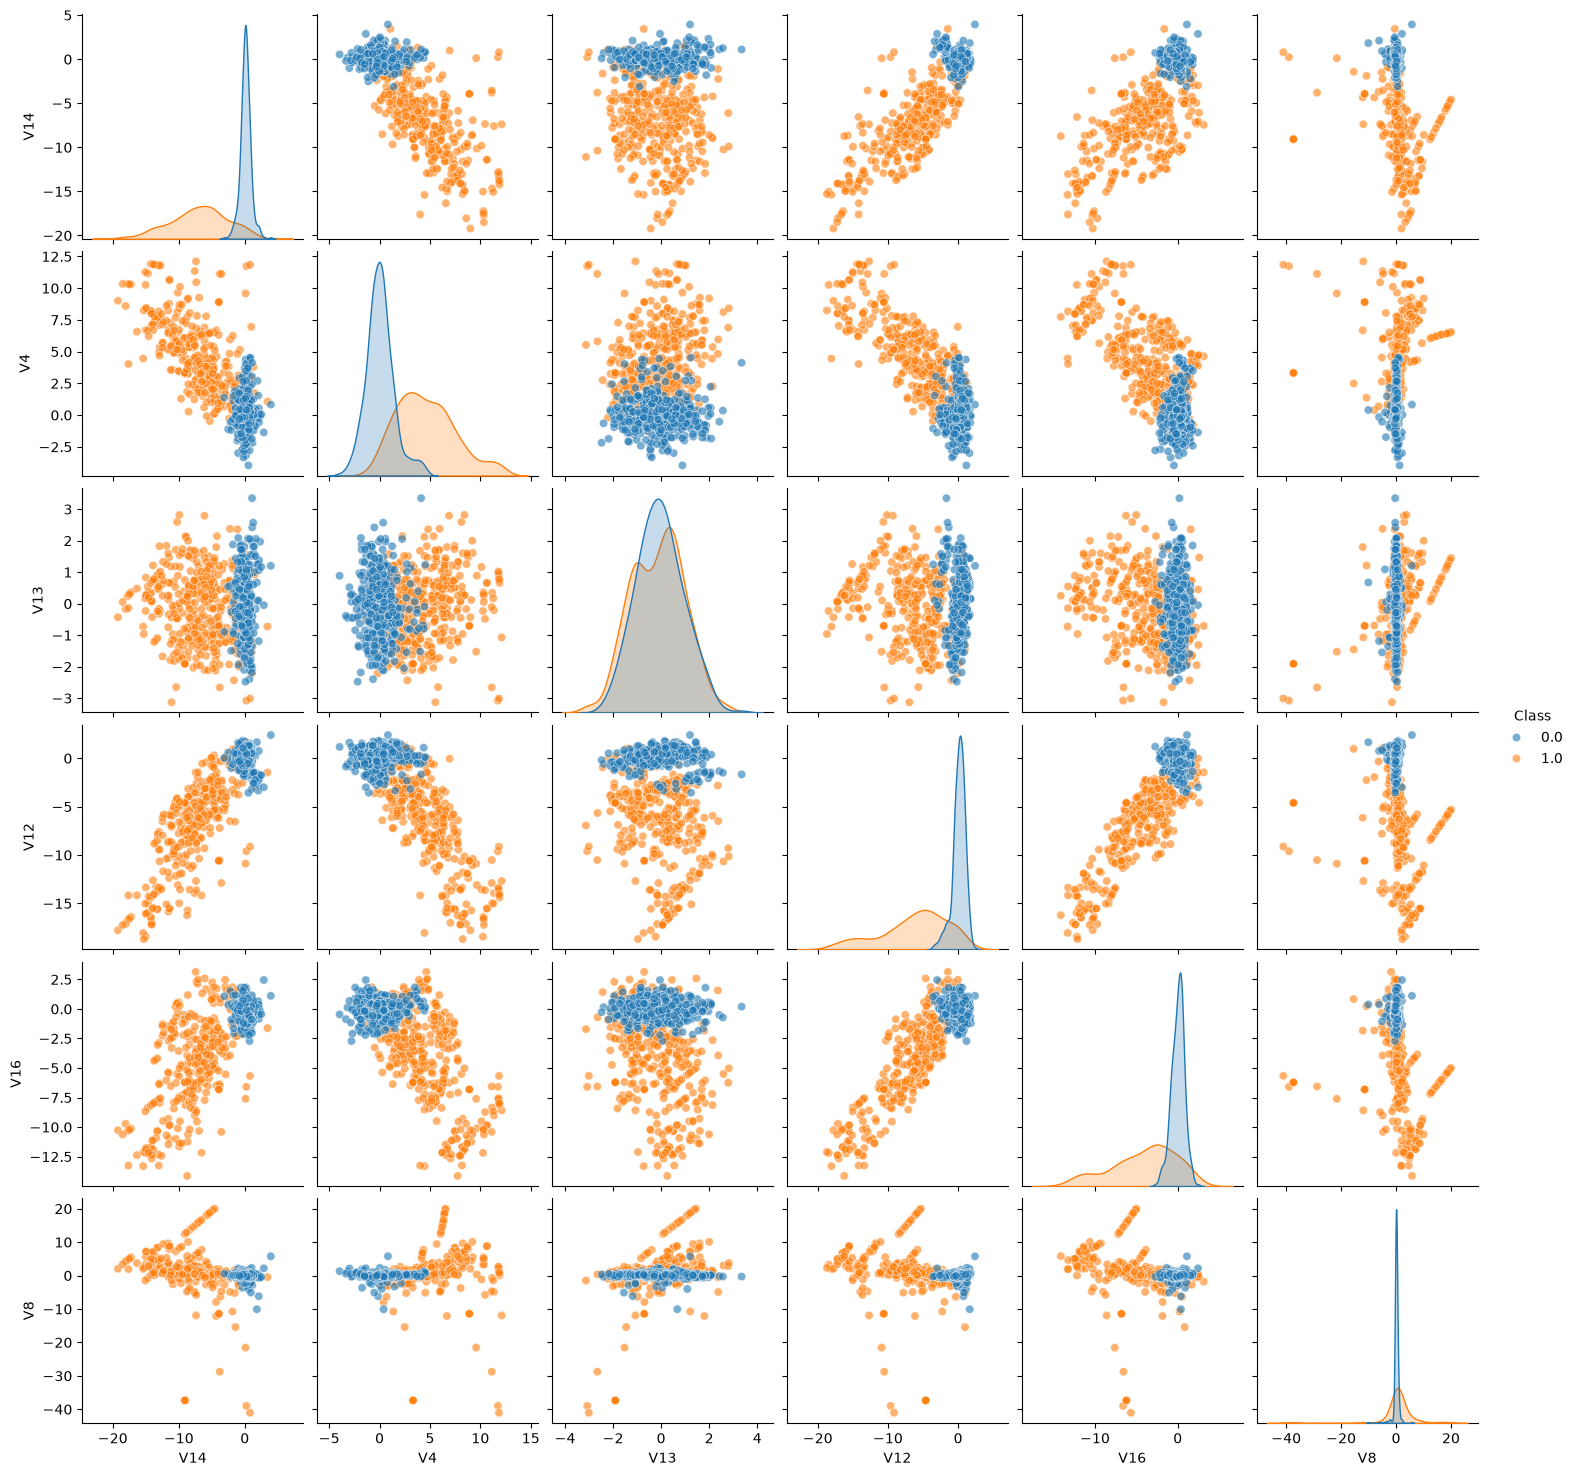

In [11]:
import seaborn as sns

combined = pd.concat(
    [df[selected_features + ['Class']][df.Class == 1],
     df[selected_features + ['Class']][df.Class == 0].sample(n=394, random_state=42).reset_index(drop=True)], 
    axis=0, 
    ignore_index=True
)


sns.pairplot(
    combined,
    hue="Class",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# estimate final

In [12]:
import statsmodels.api as sm

X_selected = sm.add_constant(
    X[selected_features],
    has_constant="add"
)

final_model = sm.Logit(y, X_selected).fit()

print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.004161
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:               227845
Model:                          Logit   Df Residuals:                   227838
Method:                           MLE   Df Model:                            6
Date:                Tue, 08 Sep 2026   Pseudo R-squ.:                  0.6730
Time:                        15:28:20   Log-Likelihood:                -948.07
converged:                       True   LL-Null:                       -2899.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.3924      0.133    -63.292      0.000      -8.652      -8.132
V14           -0.7494      0

# marginal effects

In [13]:
mfx = final_model.get_margeff(at="overall")

In [14]:
mfx = final_model.get_margeff(
    at="overall",
    dummy=True,       # appropriate handling for binary predictors
    count=True        # appropriate handling for count variables
)

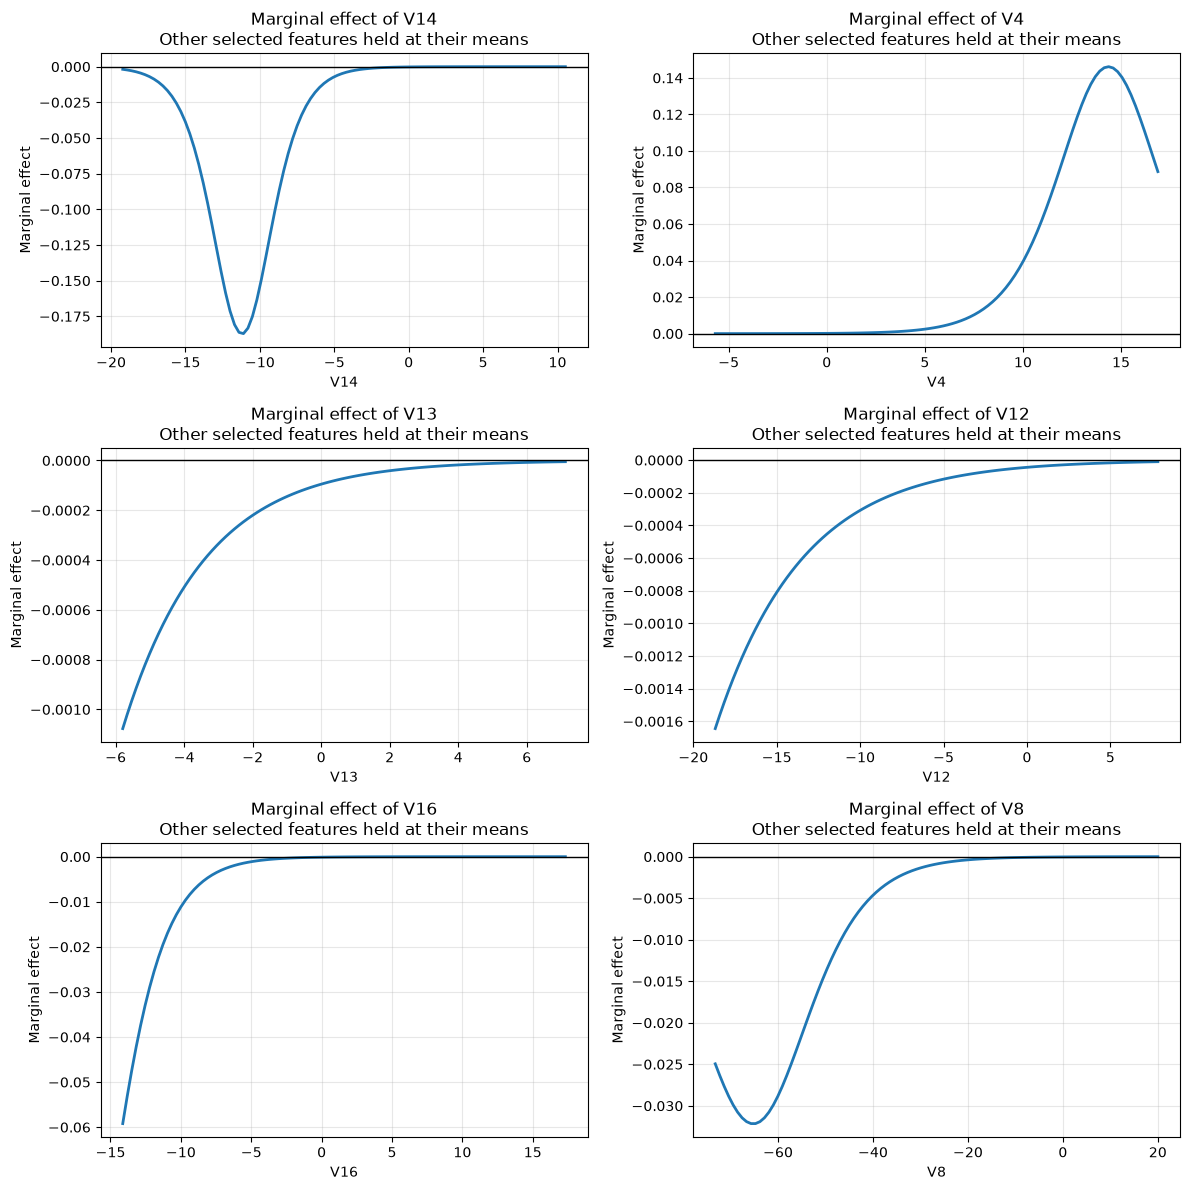

In [15]:
import math
import matplotlib.pyplot as plt

n_features = len(selected_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

for i, feature in enumerate(selected_features):
    uti.plot_logit_marginal_effect(
        model=final_model,
        data=df,
        variable=feature,
        selected_features=selected_features,
        ax=axes[i]
    )

# Hide unused axes if the number of features is not even
for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# save model

In [16]:
models['logi'] = final_model

In [17]:
with open("../data/models.pkl", "wb") as file:
    pickle.dump(models, file)